In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..
from rich import print



/Volumes/CrucialX/project-equinox


In [2]:
case_dir = "data/cases/LGAV_LFPG/"
batch_sgd_results_dir_path = f"{case_dir}gauge_pot_dis/"

In [3]:
# Look for the latest checkpoint in the `batch_sgd_results_dir_path`
import re
from pathlib import Path

def get_latest_checkpoint(results_dir_path):
    directory = Path(results_dir_path)
    
    # Pattern to match 'checkpoint_iter_X.pt' and capture X
    pattern = re.compile(r"checkpoint_iter_(\d+)\.pt")
    
    checkpoints = []
    
    # Iterate through files in the directory
    for file in directory.glob("checkpoint_iter_*.pt"):
        match = pattern.search(file.name)
        if match:
            iteration = int(match.group(1))
            checkpoints.append((iteration, file.name))
            
    if not checkpoints:
        return None
    
    # Sort by the iteration number (the first element of the tuple) and get the last one
    latest_checkpoint = max(checkpoints, key=lambda x: x[0])
    
    return latest_checkpoint[1]


latest_checkpoint_filename = batch_sgd_results_dir_path + get_latest_checkpoint(batch_sgd_results_dir_path)
print(f"Latest checkpoint: {latest_checkpoint_filename}")

Latest checkpoint: data/cases/LGAV_LFPG/gauge_pot_dis/checkpoint_iter_2001.pt

In [4]:
from equinox.posttrain import load_cost_model_parameters
from rich.console import Console
from rich.table import Table

def print_params_table(params_dict):
    console = Console()
    
    # Initialize the table
    table = Table(title="Common Parameters", show_header=True, header_style="bold magenta")
    
    table.add_column("Parameter", style="dim", width=12)
    table.add_column("Value", justify="right")

    # Add rows, formatting floats to 6 decimal places for clarity
    for key, value in params_dict.items():
        table.add_row(key, f"{value:.6f}")

    console.print(table)

params = load_cost_model_parameters(latest_checkpoint_filename)
print("[bold red]Parameters retrieved from learned cost model[/bold red]")
print_params_table(params["common"])
print(params["preference_matrix"].shape)  # (num_nodes, num_nodes)

Parameters retrieved from learned cost model

     Common Parameters     
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Parameter    ┃    Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ bias         │ 0.049132 │
│ ac_dist      │ 0.002208 │
│ time         │ 0.016457 │
└──────────────┴──────────┘

torch.Size([600, 600])

Loading route graph from /Volumes/CrucialX/project-equinox/data/cases/LGAV_LFPG/graphs/routes.gml

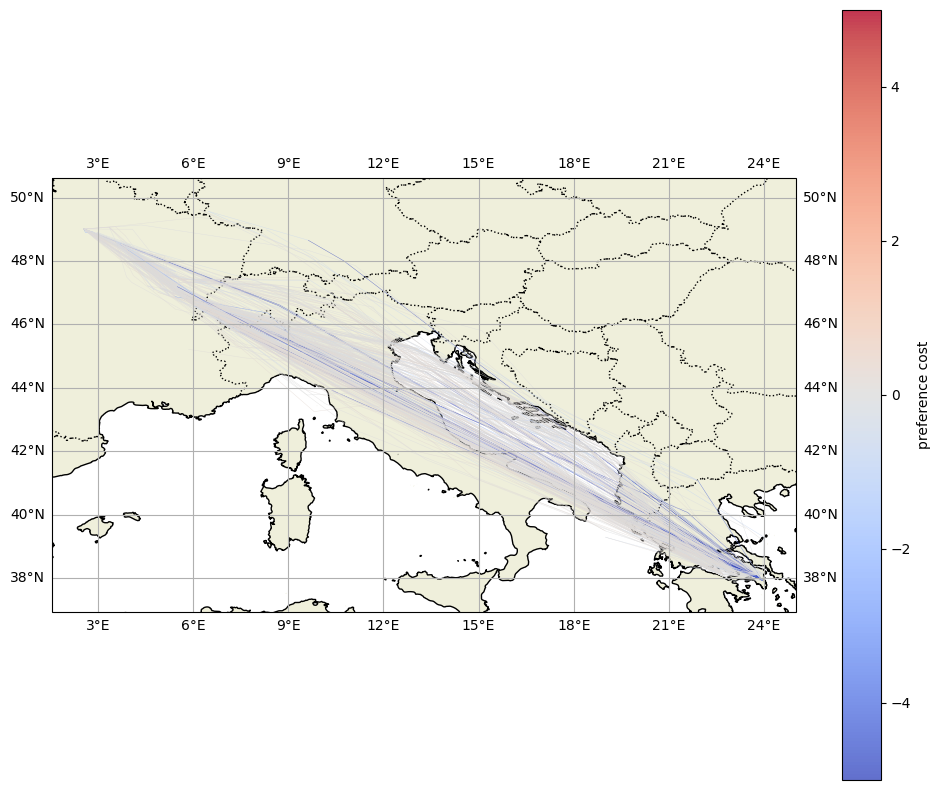

<GeoAxes: >

In [5]:
from equinox.posttrain import load_checkpoint_edge_preferences, plot_edge_preferences_cartopy

from pathlib import Path

def get_gml_path(batch_sgd_results_dir_path: str) -> str:
    """
    Recursively searches for a .gml file in the specified directory.
    Returns the absolute path to the .gml file.
    """
    directory = Path(batch_sgd_results_dir_path)
    
    # rglob("*.gml") searches recursively for all files ending in .gml
    # We use next() to get the first result since only one is guaranteed.
    try:
        gml_file = next(directory.rglob("*.gml"))
        return str(gml_file.absolute())
    except StopIteration:
        raise FileNotFoundError(f"No .gml file found in {batch_sgd_results_dir_path}")

gml_path = get_gml_path(case_dir)
print(f'Loading route graph from {gml_path}')

payload = load_checkpoint_edge_preferences(latest_checkpoint_filename, gml_path)
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=0.3,
    alpha=0.8,
    percentile=0.5,
    percentile_mode="upper", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5)
)

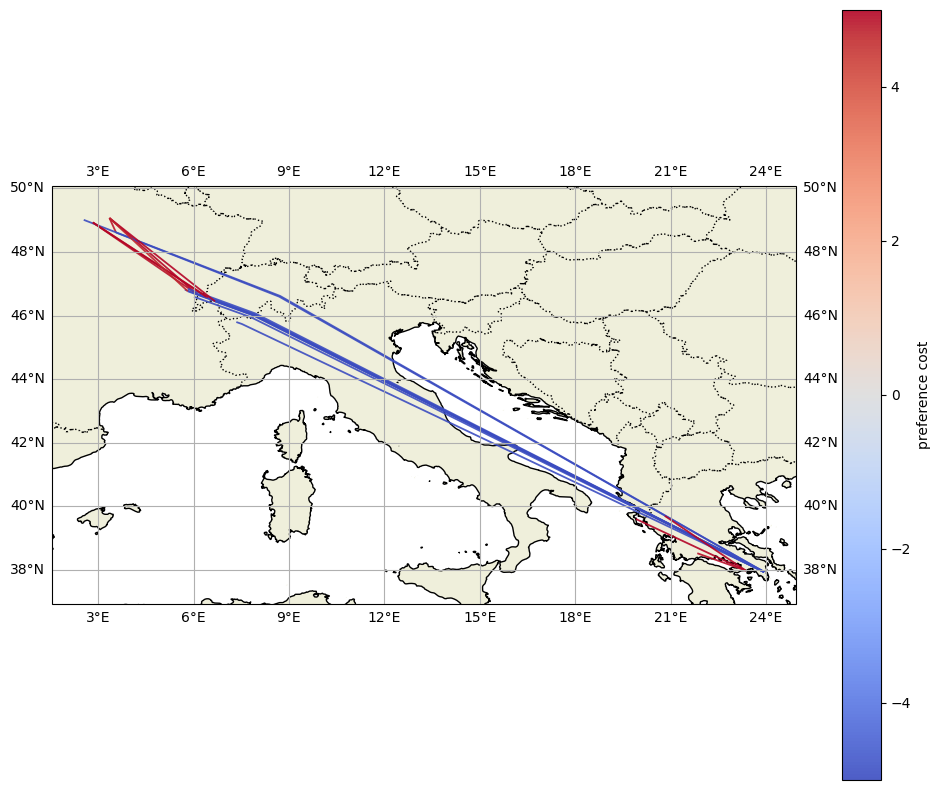

<GeoAxes: >

In [6]:
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=1.3,
    alpha=0.9,
    percentile=0.009,
    percentile_mode="contrast", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5)
)

# Route cost decomposition and inspection

In [7]:
from equinox.posttrain.cost_back_envelope import compute_route_cost_breakdown, breakdown_to_frame

reference_flight_id = "45CAB5AFR36HN"
reference_takeoff_timestamp = 1680613713

result = compute_route_cost_breakdown(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id=reference_flight_id,
    takeoff_time=reference_takeoff_timestamp
)

df = breakdown_to_frame(result["breakdown"])
print_params_table(result["totals"])
df


All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 144)
  - Goal: LFPG (idx: 262)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)


     Common Parameters      
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Parameter    ┃     Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ cost_bias    │  0.294790 │
│ cost_ac_dist │  1.789053 │
│ cost_time    │  2.665422 │
│ cost_prefer… │ -0.215685 │
│ cost_common  │  4.749266 │
│ cost_total   │  4.533581 │
└──────────────┴───────────┘

,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGKN,144,356,12.129164,25.460000,-3.205034,False,1.0,3.088085,1.628823,0.049132,0.002208,0.016457,0.049132,0.006820,0.026805,-0.032194,0.082757,0.050563
1,LGKN,RIMAX,356,562,58.379740,25.460000,-31.098999,False,1.0,14.863482,8.361843,0.049132,0.002208,0.016457,0.049132,0.032825,0.137609,-0.016740,0.219566,0.202826
2,RIMAX,FASAN_32,562,359,291.639332,41.179159,-19.364985,False,1.0,120.094623,40.633853,0.049132,0.002208,0.016457,0.049132,0.265220,0.668704,-0.054274,0.983055,0.928781
3,FASAN_32,URQAP,359,169,639.476695,83.688177,-9.552148,False,1.0,535.166388,87.112700,0.049132,0.002208,0.016457,0.049132,1.181873,1.433598,-0.054274,2.664603,2.610329
4,URQAP,OKIPA,169,112,124.213985,80.074109,-33.487316,False,1.0,99.463241,17.893426,0.049132,0.002208,0.016457,0.049132,0.219657,0.294469,-0.028858,0.563257,0.534399
5,OKIPA,LFPG,112,262,46.745095,80.070000,-7.199062,False,1.0,37.428797,6.334010,0.049132,0.002208,0.016457,0.049132,0.082659,0.104238,-0.029344,0.236028,0.206683


# Inference/Sampling

In [8]:
from pathlib import Path 

from equinox.sampling.pipeline import compute_4d_path_for_dataset
from equinox.posttrain.plot_sample_routes import plot_sample_routes

res = compute_4d_path_for_dataset(
    case_dir=Path("data/cases/LGAV_LFPG"),
    checkpoint_path=Path(latest_checkpoint_filename),
    flight_id=reference_flight_id,
    takeoff_timestamp=reference_takeoff_timestamp,
    n_samples=200,
    policy="sample",
    output_dir=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}"),
    seed=7,
)

All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 144)
  - Goal: LFPG (idx: 262)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)
Goal LFPG reached at step 8.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 10.
Goal LFPG reached at step 7.
Goal LFPG reached at step 11.
Goal LFPG reached at step 8.
Goal LFPG reached at step 8.
Goal LFPG reached at step 7.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 10.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 6.
Goal LFPG reached at step 7.
Goal LFPG reached at step 5.
Goal LFPG reached at step

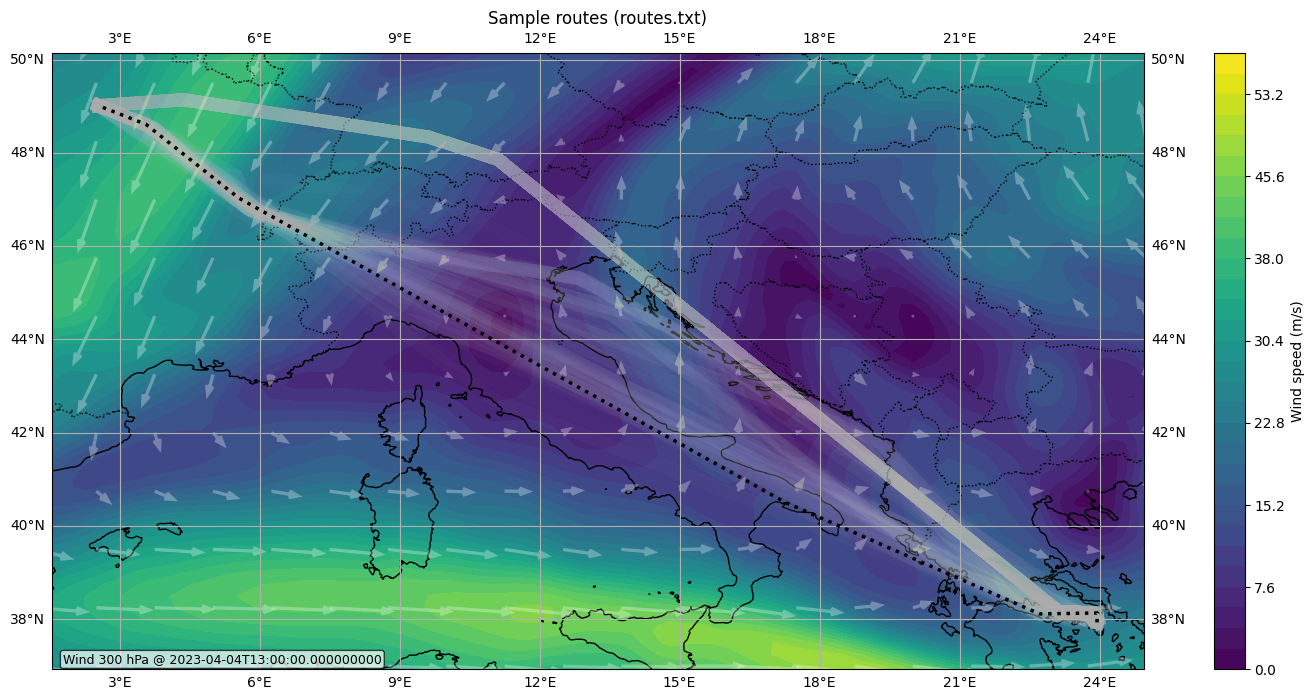

(<Figure size 1800x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Sample routes (routes.txt)'}>)

In [9]:

plot_sample_routes(
    case_dir=Path("data/cases/LGAV_LFPG"),
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt"),
    show=True,
    show_waypoints=False,
    route_alpha=0.01,
    reference_flight_id=reference_flight_id,
    reference_takeoff_timestamp=reference_takeoff_timestamp,
    plot_wind = True,
    show_quiver = True
)

All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 144)
  - Goal: LFPG (idx: 262)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)
Route 1/20 (of 126): LGAV -> GERMI -> DISUN -> KUNOD -> RANUX -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,GERMI,41.135,25.460,-23.822,False,0.049,0.023,0.095,-0.014,0.153
1,GERMI,DISUN,783.923,46.291,-60.534,False,0.049,0.801,1.987,-0.043,2.795
2,DISUN,KUNOD,66.100,100.020,-50.229,False,0.049,0.146,0.163,-0.043,0.315
3,KUNOD,RANUX,213.579,86.932,-42.924,False,0.049,0.410,0.518,-0.043,0.934
4,RANUX,LFPG,71.755,80.070,-11.019,False,0.049,0.127,0.161,-0.043,0.294


Totals: bias=0.246, ac_dist=1.507, time=2.925, preference=-0.186, total=4.492


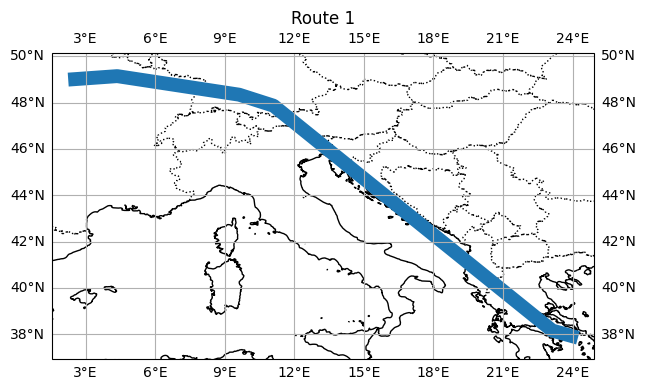

Route 2/20 (of 126): LGAV -> LGKN -> GERMI -> DISUN -> KUNOD -> RANUX -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,GERMI,39.143,25.460,-31.051,False,0.049,0.022,0.092,-0.028,0.135
2,GERMI,DISUN,783.923,46.291,-60.534,False,0.049,0.801,1.987,-0.043,2.795
3,DISUN,KUNOD,66.100,100.020,-50.229,False,0.049,0.146,0.163,-0.043,0.315
4,KUNOD,RANUX,213.579,86.932,-42.924,False,0.049,0.410,0.518,-0.043,0.934
5,RANUX,LFPG,71.755,80.070,-11.019,False,0.049,0.127,0.161,-0.043,0.294


Totals: bias=0.295, ac_dist=1.513, time=2.950, preference=-0.232, total=4.526


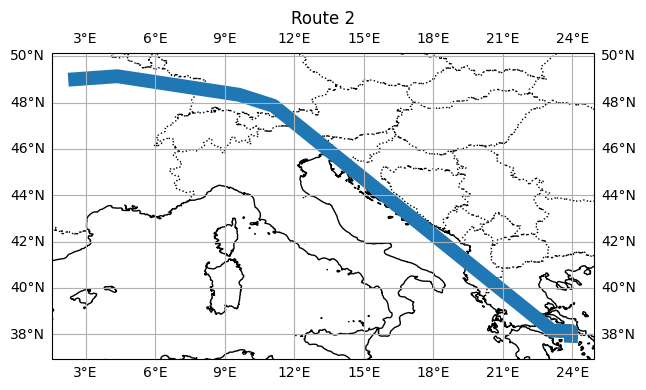

Route 3/20 (of 126): LGAV -> XORKI -> GERMI -> DISUN -> KUNOD -> RANUX -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,XORKI,24.887,25.460,-24.425,False,0.049,0.014,0.058,-0.016,0.105
1,XORKI,GERMI,18.162,25.460,-30.789,False,0.049,0.010,0.043,0.020,0.122
2,GERMI,DISUN,783.923,46.291,-60.534,False,0.049,0.801,1.987,-0.043,2.795
3,DISUN,KUNOD,66.100,100.020,-50.229,False,0.049,0.146,0.163,-0.043,0.315
4,KUNOD,RANUX,213.579,86.932,-42.924,False,0.049,0.410,0.518,-0.043,0.934
5,RANUX,LFPG,71.755,80.070,-11.019,False,0.049,0.127,0.161,-0.043,0.294


Totals: bias=0.295, ac_dist=1.509, time=2.931, preference=-0.167, total=4.567


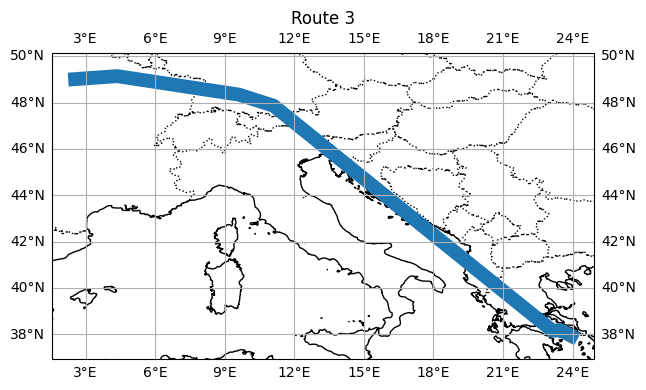

Route 4/20 (of 126): LGAV -> LGTT -> XORKI -> GERMI -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGTT,12.831,25.460,-23.770,False,0.049,0.007,0.030,0.073,0.159
1,LGTT,XORKI,13.457,25.460,-41.152,False,0.049,0.008,0.032,0.055,0.144
2,XORKI,GERMI,18.162,25.460,-30.789,False,0.049,0.010,0.043,0.020,0.122
3,GERMI,LFPG,1100.755,73.318,0.000,True,0.049,1.782,2.415,-0.085,4.162


Totals: bias=0.197, ac_dist=1.807, time=2.520, preference=0.063, total=4.587


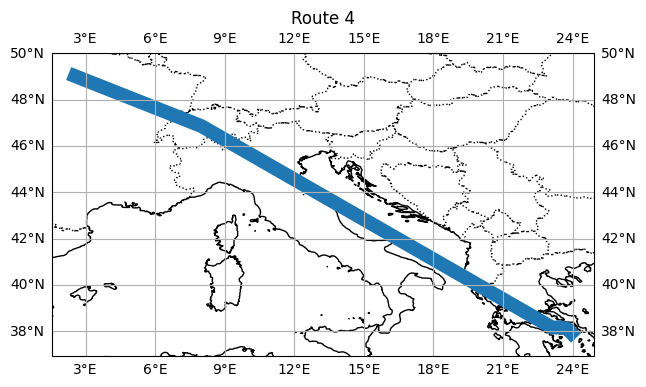

Route 5/20 (of 126): LGAV -> XORKI -> OLKIS -> OKIPA -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,XORKI,24.887,25.460,-24.425,False,0.049,0.014,0.058,-0.016,0.105
1,XORKI,OLKIS,686.832,57.790,-55.724,False,0.049,0.877,1.720,-0.078,2.568
2,OLKIS,OKIPA,398.390,91.002,-34.500,False,0.049,0.801,0.947,-0.079,1.718
3,OKIPA,LFPG,46.745,80.070,-10.627,False,0.049,0.083,0.105,-0.029,0.207


Totals: bias=0.197, ac_dist=1.774, time=2.830, preference=-0.202, total=4.598


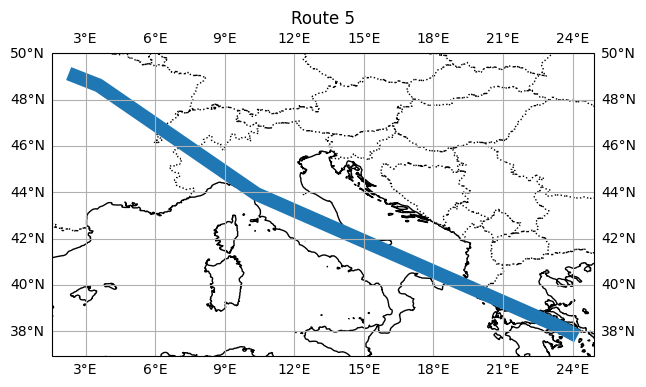

Route 6/20 (of 126): LGAV -> GERMI -> LSGB -> OKIPA -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,GERMI,41.135,25.460,-23.822,False,0.049,0.023,0.095,-0.014,0.153
1,GERMI,LSGB,864.059,65.412,-54.565,False,0.049,1.248,2.158,-0.034,3.421
2,LSGB,OKIPA,198.173,94.480,-30.302,False,0.049,0.413,0.466,-0.034,0.895
3,OKIPA,LFPG,46.745,80.070,-10.627,False,0.049,0.083,0.105,-0.029,0.207


Totals: bias=0.197, ac_dist=1.767, time=2.824, preference=-0.111, total=4.677


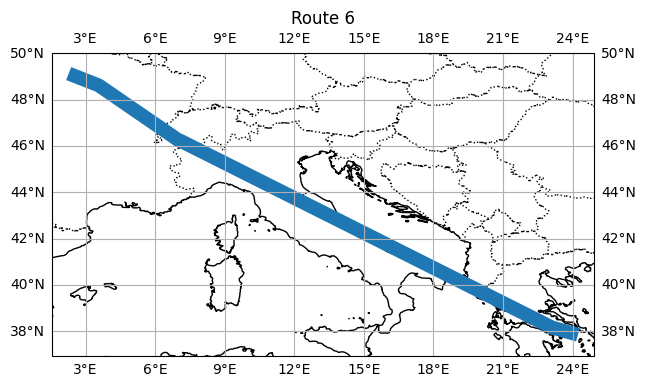

Route 7/20 (of 126): LGAV -> LGKN -> ROPOX -> MINTU -> ADOSA_14 -> LFGX -> LFGJ -> URELO -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,ROPOX,9.115,25.460,-32.254,False,0.049,0.005,0.022,0.092,0.168
2,ROPOX,MINTU,551.443,36.530,-67.941,False,0.049,0.445,1.425,-0.122,1.797
3,MINTU,ADOSA_14,168.750,60.769,-59.026,False,0.049,0.226,0.426,-0.021,0.681
4,ADOSA_14,LFGX,231.585,112.710,-51.880,False,0.049,0.576,0.574,-0.021,1.179
5,LFGX,LFGJ,23.034,80.070,-33.388,False,0.049,0.041,0.055,-0.052,0.093
6,LFGJ,URELO,113.074,80.073,-23.711,False,0.049,0.200,0.262,-0.049,0.462
7,URELO,LFPG,54.726,80.070,-11.520,False,0.049,0.097,0.123,-0.000,0.269


Totals: bias=0.393, ac_dist=1.597, time=2.915, preference=-0.204, total=4.701


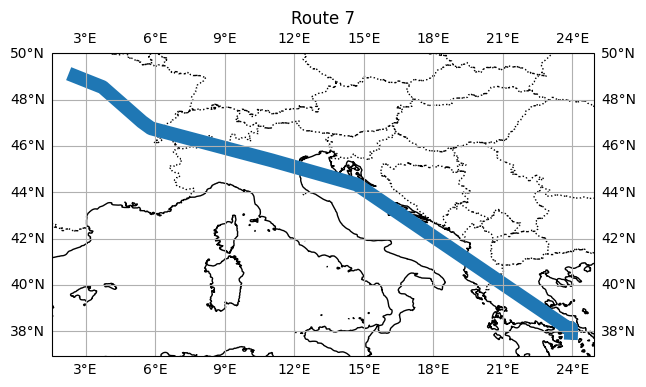

Route 8/20 (of 126): LGAV -> XORKI -> UNKIR -> EPURI -> LFFH -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,XORKI,24.887,25.460,-24.425,False,0.049,0.014,0.058,-0.016,0.105
1,XORKI,UNKIR,939.579,68.602,-51.288,False,0.049,1.423,2.327,-0.014,3.786
2,UNKIR,EPURI,129.833,80.075,-26.272,False,0.049,0.230,0.303,-0.093,0.488
3,EPURI,LFFH,38.262,80.070,-15.190,False,0.049,0.068,0.087,-0.056,0.148
4,LFFH,LFPG,31.977,80.070,-3.868,False,0.049,0.057,0.071,0.003,0.179


Totals: bias=0.246, ac_dist=1.791, time=2.845, preference=-0.176, total=4.706


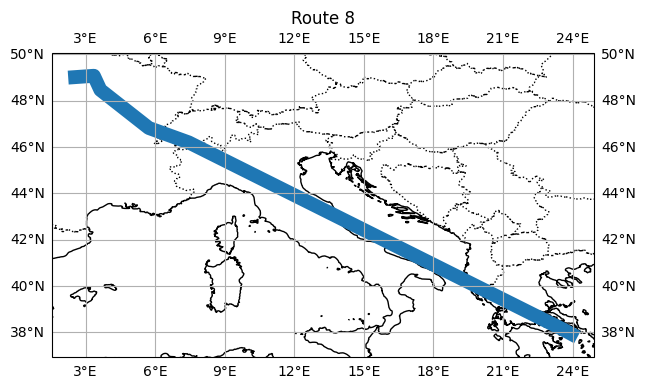

Route 9/20 (of 126): LGAV -> LGKN -> GERMI_00 -> UNKIR -> RLP_24 -> OKIPA -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,GERMI_00,41.647,25.460,-26.125,False,0.049,0.023,0.097,-0.069,0.101
2,GERMI_00,UNKIR,926.528,68.221,-50.915,False,0.049,1.396,2.292,-0.058,3.680
3,UNKIR,RLP_24,49.665,80.070,-22.260,False,0.049,0.088,0.115,0.014,0.266
4,RLP_24,OKIPA,90.262,80.072,-24.203,False,0.049,0.160,0.209,0.014,0.432
5,OKIPA,LFPG,46.745,80.070,-10.627,False,0.049,0.083,0.105,-0.029,0.207


Totals: bias=0.295, ac_dist=1.756, time=2.846, preference=-0.160, total=4.737


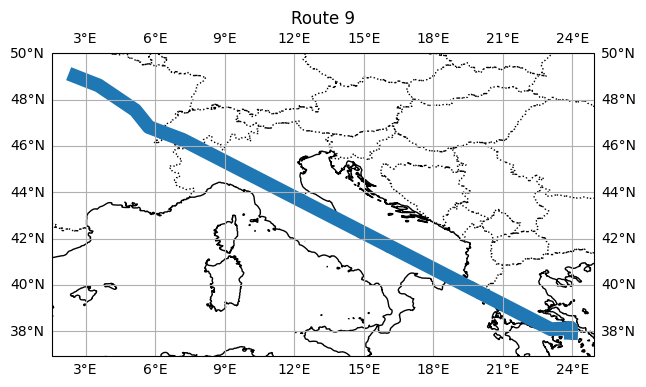

Route 10/20 (of 126): LGAV -> LGKN -> GERMI_00 -> UNKIR -> JAVVU_37 -> LFFH -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,GERMI_00,41.647,25.460,-26.125,False,0.049,0.023,0.097,-0.069,0.101
2,GERMI_00,UNKIR,926.528,68.221,-50.915,False,0.049,1.396,2.292,-0.058,3.680
3,UNKIR,JAVVU_37,24.706,80.070,-19.723,False,0.049,0.044,0.057,-0.014,0.135
4,JAVVU_37,LFFH,141.319,80.075,-22.520,False,0.049,0.250,0.326,-0.014,0.611
5,LFFH,LFPG,31.977,80.070,-3.868,False,0.049,0.057,0.071,0.003,0.179


Totals: bias=0.295, ac_dist=1.776, time=2.871, preference=-0.185, total=4.758


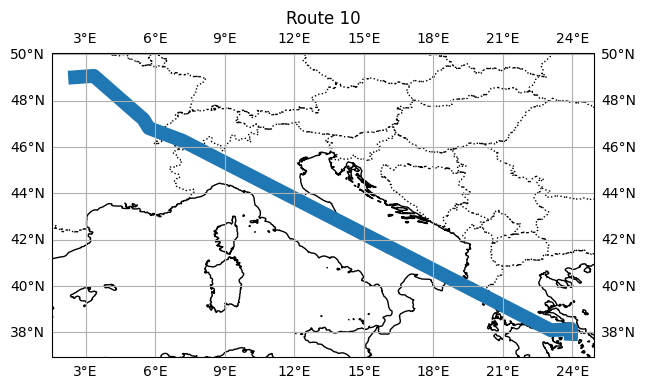

Route 11/20 (of 126): LGAV -> LGKN -> PIKAD -> DINOX -> OKIPA -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,PIKAD,59.477,25.460,-24.870,False,0.049,0.033,0.138,-0.035,0.185
2,PIKAD,DINOX,895.851,68.950,-51.494,False,0.049,1.364,2.220,0.063,3.696
3,DINOX,OKIPA,155.951,80.077,-26.225,False,0.049,0.276,0.363,-0.067,0.621
4,OKIPA,LFPG,46.745,80.070,-10.627,False,0.049,0.083,0.105,-0.029,0.207


Totals: bias=0.246, ac_dist=1.763, time=2.854, preference=-0.102, total=4.761


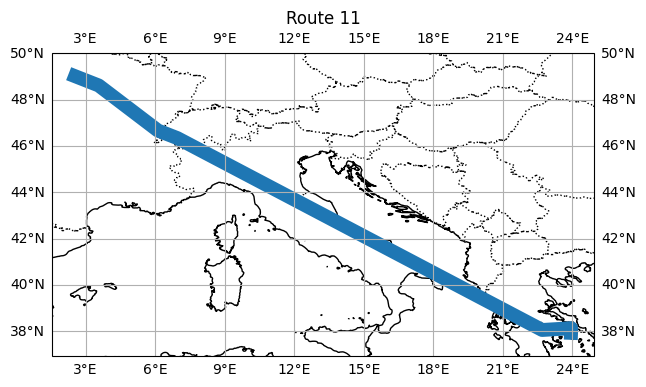

Route 12/20 (of 126): LGAV -> LGTT -> XORKI -> GERMI -> DISUN -> KUNOD -> RANUX -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGTT,12.831,25.460,-23.770,False,0.049,0.007,0.030,0.073,0.159
1,LGTT,XORKI,13.457,25.460,-41.152,False,0.049,0.008,0.032,0.055,0.144
2,XORKI,GERMI,18.162,25.460,-30.789,False,0.049,0.010,0.043,0.020,0.122
3,GERMI,DISUN,783.923,46.291,-60.534,False,0.049,0.801,1.987,-0.043,2.795
4,DISUN,KUNOD,66.100,100.020,-50.229,False,0.049,0.146,0.163,-0.043,0.315
5,KUNOD,RANUX,213.579,86.932,-42.924,False,0.049,0.410,0.518,-0.043,0.934
6,RANUX,LFPG,71.755,80.070,-11.019,False,0.049,0.127,0.161,-0.043,0.294


Totals: bias=0.344, ac_dist=1.509, time=2.935, preference=-0.024, total=4.764


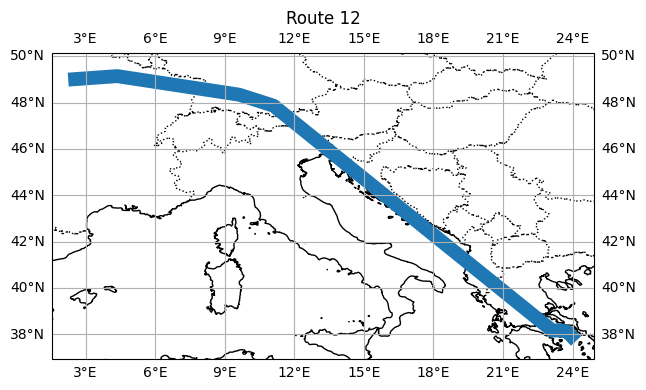

Route 13/20 (of 126): LGAV -> GERMI -> GARTA -> GOKEL_29 -> PUL_12 -> LFGJ -> URELO -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,GERMI,41.135,25.460,-23.822,False,0.049,0.023,0.095,-0.014,0.153
1,GERMI,GARTA,112.527,25.460,-61.237,False,0.049,0.063,0.286,-0.023,0.375
2,GARTA,GOKEL_29,122.651,25.460,-69.487,False,0.049,0.069,0.318,-0.023,0.413
3,GOKEL_29,PUL_12,348.005,56.209,-59.937,False,0.049,0.432,0.881,0.010,1.372
4,PUL_12,LFGJ,371.445,97.035,-51.636,False,0.049,0.796,0.921,-0.040,1.726
5,LFGJ,URELO,113.074,80.073,-23.711,False,0.049,0.200,0.262,-0.049,0.462
6,URELO,LFPG,54.726,80.070,-11.520,False,0.049,0.097,0.123,-0.000,0.269


Totals: bias=0.344, ac_dist=1.680, time=2.886, preference=-0.139, total=4.771


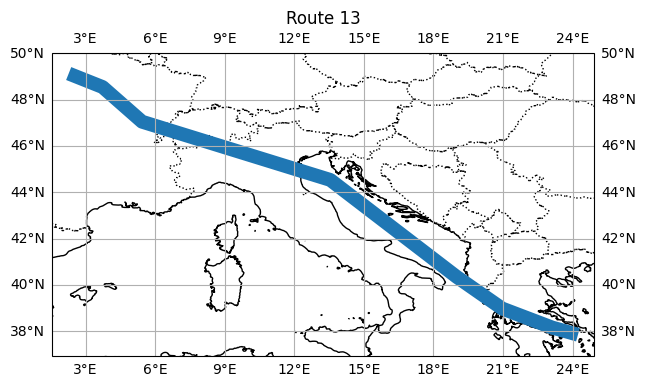

Route 14/20 (of 126): LGAV -> XORKI -> UNKIR -> LFSD -> OKIPA -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,XORKI,24.887,25.460,-24.425,False,0.049,0.014,0.058,-0.016,0.105
1,XORKI,UNKIR,939.579,68.602,-51.288,False,0.049,1.423,2.327,-0.014,3.786
2,UNKIR,LFSD,37.409,80.070,-31.527,False,0.049,0.066,0.088,0.011,0.215
3,LFSD,OKIPA,101.586,80.072,-22.335,False,0.049,0.180,0.235,0.011,0.475
4,OKIPA,LFPG,46.745,80.070,-10.627,False,0.049,0.083,0.105,-0.029,0.207


Totals: bias=0.246, ac_dist=1.766, time=2.812, preference=-0.036, total=4.788


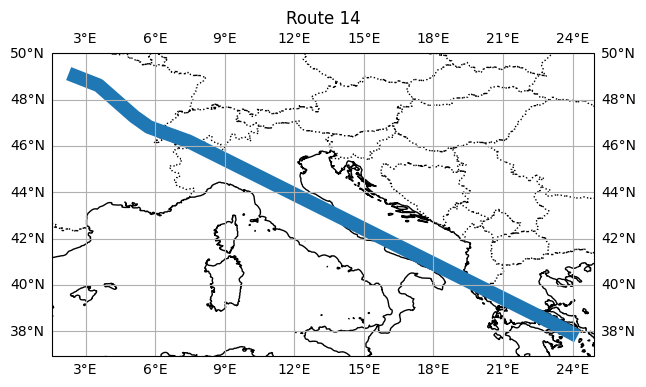

Route 15/20 (of 126): LGAV -> ROPOX -> MINTU -> ADOSA_14 -> LFGX -> LFGJ -> URELO -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,ROPOX,16.405,25.460,-10.927,False,0.049,0.009,0.037,0.215,0.310
1,ROPOX,MINTU,551.443,36.530,-67.941,False,0.049,0.445,1.425,-0.122,1.797
2,MINTU,ADOSA_14,168.750,60.769,-59.026,False,0.049,0.226,0.426,-0.021,0.681
3,ADOSA_14,LFGX,231.585,112.710,-51.880,False,0.049,0.576,0.574,-0.021,1.179
4,LFGX,LFGJ,23.034,80.070,-33.388,False,0.049,0.041,0.055,-0.052,0.093
5,LFGJ,URELO,113.074,80.073,-23.711,False,0.049,0.200,0.262,-0.049,0.462
6,URELO,LFPG,54.726,80.070,-11.520,False,0.049,0.097,0.123,-0.000,0.269


Totals: bias=0.344, ac_dist=1.594, time=2.902, preference=-0.049, total=4.791


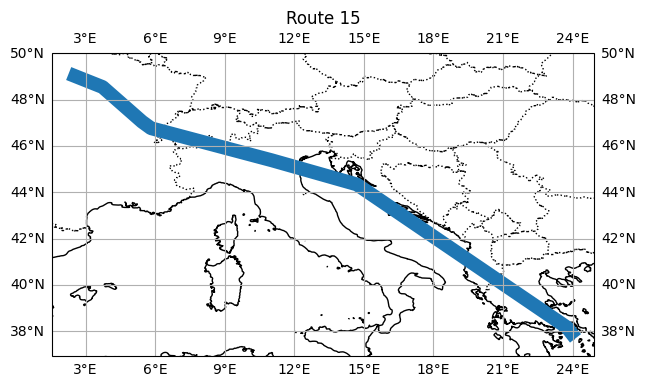

Route 16/20 (of 126): LGAV -> GERMI_00 -> UNKIR -> EPURI -> LFFH -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,GERMI_00,42.322,25.460,-22.005,False,0.049,0.024,0.098,0.130,0.301
1,GERMI_00,UNKIR,926.528,68.221,-50.915,False,0.049,1.396,2.292,-0.058,3.680
2,UNKIR,EPURI,129.833,80.075,-26.272,False,0.049,0.230,0.303,-0.093,0.488
3,EPURI,LFFH,38.262,80.070,-15.190,False,0.049,0.068,0.087,-0.056,0.148
4,LFFH,LFPG,31.977,80.070,-3.868,False,0.049,0.057,0.071,0.003,0.179


Totals: bias=0.246, ac_dist=1.774, time=2.850, preference=-0.073, total=4.796


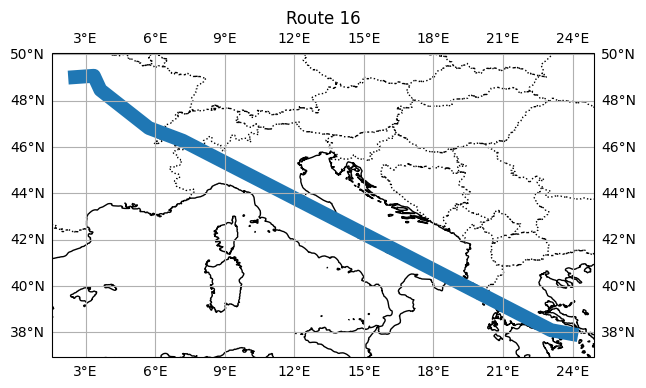

Route 17/20 (of 126): LGAV -> XORKI -> UNKIR -> NANOP -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,XORKI,24.887,25.460,-24.425,False,0.049,0.014,0.058,-0.016,0.105
1,XORKI,UNKIR,939.579,68.602,-51.288,False,0.049,1.423,2.327,-0.014,3.786
2,UNKIR,NANOP,105.715,80.072,-24.421,False,0.049,0.187,0.245,0.045,0.526
3,NANOP,LFPG,80.749,80.070,-13.435,False,0.049,0.143,0.183,0.007,0.382


Totals: bias=0.197, ac_dist=1.767, time=2.813, preference=0.022, total=4.799


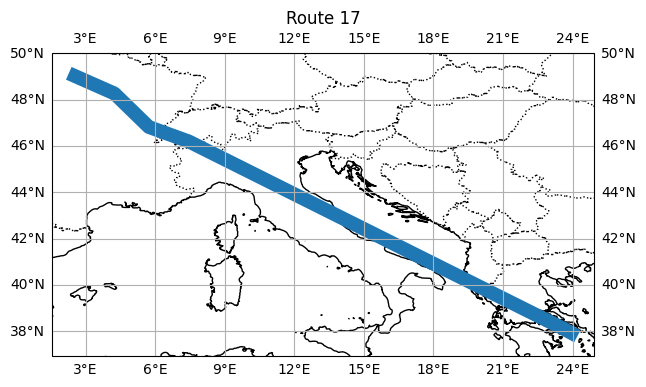

Route 18/20 (of 126): LGAV -> LGKN -> GERMI_00 -> RIMAX -> KOFER -> TILVO -> PUNSA -> LFGX -> LFGJ -> URELO -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,GERMI_00,41.647,25.460,-26.125,False,0.049,0.023,0.097,-0.069,0.101
2,GERMI_00,RIMAX,16.869,25.460,-40.855,False,0.049,0.009,0.041,0.068,0.167
3,RIMAX,KOFER,294.918,35.613,0.000,True,0.049,0.232,0.647,-0.011,0.917
4,KOFER,TILVO,22.246,38.999,-71.942,False,0.049,0.019,0.058,-0.011,0.115
5,TILVO,PUNSA,500.411,60.924,-61.060,False,0.049,0.673,1.270,-0.011,1.982
6,PUNSA,LFGX,100.553,152.437,-49.815,False,0.049,0.339,0.248,0.009,0.645
7,LFGX,LFGJ,23.034,80.070,-33.388,False,0.049,0.041,0.055,-0.052,0.093
8,LFGJ,URELO,113.074,80.073,-23.711,False,0.049,0.200,0.262,-0.049,0.462
9,URELO,LFPG,54.726,80.070,-11.520,False,0.049,0.097,0.123,-0.000,0.269


Totals: bias=0.491, ac_dist=1.640, time=2.829, preference=-0.159, total=4.802


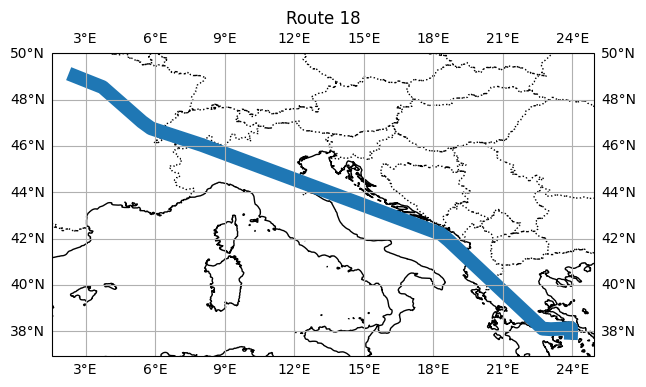

Route 19/20 (of 126): LGAV -> LGKN -> GERMI_00 -> XANIS -> DINOX -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGKN,12.129,25.460,-18.079,False,0.049,0.007,0.028,-0.032,0.051
1,LGKN,GERMI_00,41.647,25.460,-26.125,False,0.049,0.023,0.097,-0.069,0.101
2,GERMI_00,XANIS,50.634,25.460,-62.745,False,0.049,0.028,0.129,-0.024,0.183
3,XANIS,DINOX,857.650,70.837,-51.336,False,0.049,1.342,2.124,0.022,3.537
4,DINOX,LFPG,201.235,80.082,-18.330,False,0.049,0.356,0.460,0.067,0.933


Totals: bias=0.246, ac_dist=1.756, time=2.838, preference=-0.036, total=4.805


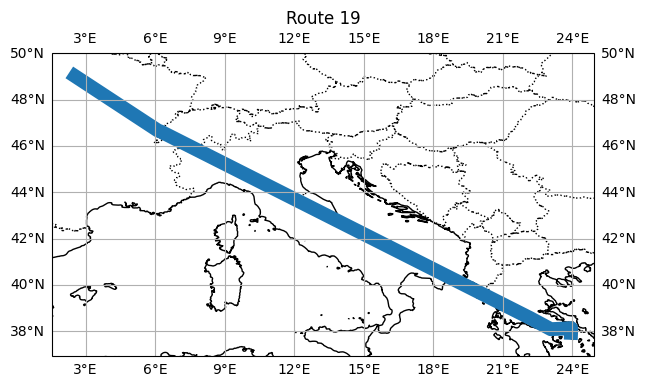

Route 20/20 (of 126): LGAV -> LGTT -> VARDI -> KRK_30 -> MOLUS -> LFPG


,u_node,v_node,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_total
0,LGAV,LGTT,12.831,25.460,-23.770,False,0.049,0.007,0.030,0.073,0.159
1,LGTT,VARDI,92.618,25.460,-49.199,False,0.049,0.052,0.228,-0.043,0.286
2,VARDI,KRK_30,95.932,25.460,-59.021,False,0.049,0.054,0.242,-0.043,0.303
3,KRK_30,MOLUS,727.620,76.152,-53.541,False,0.049,1.224,1.812,-0.043,3.042
4,MOLUS,LFPG,227.044,88.258,-20.046,False,0.049,0.443,0.521,0.010,1.023


Totals: bias=0.246, ac_dist=1.779, time=2.834, preference=-0.046, total=4.813


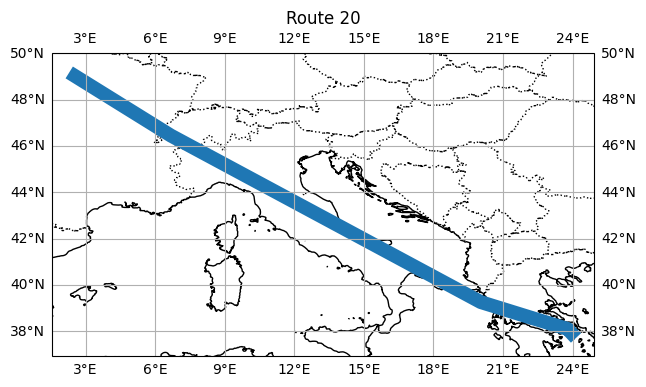

[{'route_nodes': ['LGAV', 'GERMI', 'DISUN', 'KUNOD', 'RANUX', 'LFPG'],
  'breakdown': [{'u_node': 'LGAV',
    'v_node': 'GERMI',
    'u_idx': 144,
    'v_idx': 232,
    'distance': 41.13454431417115,
    'airspace_charge': 25.46,
    'tailwind_kts': -23.821555137634277,
    'tailwind_is_fallback': False,
    'feature_bias': 1.0,
    'feature_ac_dist': 10.472854982387975,
    'feature_time': 5.791171957669827,
    'weight_bias': 0.04913172498345375,
    'weight_ac_dist': 0.002208422403782606,
    'weight_time': 0.016456814482808113,
    'cost_bias': 0.04913172498345375,
    'cost_ac_dist': 0.023128487574671897,
    'cost_time': 0.09530424254541303,
    'cost_preference': -0.01445120107382536,
    'cost_common': 0.16756445510353868,
    'cost_total': 0.15311325402971332},
   {'u_node': 'GERMI',
    'v_node': 'DISUN',
    'u_idx': 232,
    'v_idx': 395,
    'distance': 783.9229920858999,
    'airspace_charge': 46.29113542932636,
    'tailwind_kts': -60.5341911315918,
    'tailwind_is_fall

In [10]:
from equinox.posttrain.cost_back_envelope import compute_routes_cost_breakdowns


compute_routes_cost_breakdowns(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id="46B825AEE612",
    takeoff_time="1682767235",
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt")
)